# 1️⃣ Importation & Exploration

In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("bank-transactions.csv")
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.describe(include='all'))
missing = df.isnull().mean() * 100
print(missing.sort_values(ascending=False))
duplicates = df[df.duplicated(subset='transaction_id', keep=False)]
print(duplicates)

(2060, 16)
  transaction_id client_id     date_transaction  montant devise  \
0      TXN000559   CLI0060  2022-04-19 02:31:00  2050.42    EUR   
1      TXN001154   CLI0057  2024-06-20 20:51:00  -123.66    GBP   
2      TXN000764   CLI0015  2024-08-28 05:03:00  -396.17    EUR   
3      TXN001598   CLI0045  2024-01-07 08:16:00    225.2    EUR   
4      TXN001873   CLI0034  2024-08-11 19:52:00   935.32    EUR   

   taux_change_eur  montant_eur      categorie              produit  \
0             1.00      2050.42  Depot especes       Compte Epargne   
1             0.86      -143.79    Retrait DAB  Credit Consommation   
2             1.00      -396.17    Prelevement                  PEA   
3             1.00       225.20    Paiement CB  Credit Consommation   
4             1.00       935.32       Interets    Credit Immobilier   

                 agence type_operation    statut  score_credit_client  \
0  Marseille-Vieux-Port         Credit  Complete                  NaN   
1            

# 2️⃣ Nettoyage des données

In [77]:
df = df.drop_duplicates(subset='transaction_id', keep='first')
df['date_transaction'] = pd.to_datetime(df['date_transaction'], errors='coerce')
df['montant'] = df['montant'].astype(str).str.replace(',', '.').astype(float)
df['solde_avant'] = df['solde_avant'].astype(str).str.replace(' EUR', '').astype(float)
# Devise en majuscule
df['devise'] = df['devise'].str.upper()
# Segment client
df['segment_client'] = df['segment_client'].str.capitalize()
# Nettoyage 
df['agence'] = df['agence'].str.strip()
# Traitement valeurs manquantes
df['score_credit_client'] = df['score_credit_client'].fillna(df['score_credit_client'].median())
df['segment_client'] = df['segment_client'].fillna(df['segment_client'].mode()[0])
df['agence'] = df['agence'].fillna("Unknown")
df

,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,agence,type_operation,statut,score_credit_client,segment_client,solde_avant,taux_interet
0,TXN000559,CLI0060,2022-04-19 02:31:00,2050.42,EUR,1.00,2050.42,Depot especes,Compte Epargne,Marseille-Vieux-Port,Credit,Complete,645.0,Premium,16415.10,NaN
1,TXN001154,CLI0057,2024-06-20 20:51:00,-123.66,GBP,0.86,-143.79,Retrait DAB,Credit Consommation,Unknown,Debit,Rejete,435.0,Risque,42890.81,NaN
2,TXN000764,CLI0015,2024-08-28 05:03:00,-396.17,EUR,1.00,-396.17,Prelevement,PEA,Lyon-Part-Dieu,Debit,Complete,648.0,Standard,48489.38,NaN
3,TXN001598,CLI0045,2024-01-07 08:16:00,225.20,EUR,1.00,225.20,Paiement CB,Credit Consommation,Bordeaux-Meriadeck,Credit,Complete,704.0,Standard,43962.51,NaN
4,TXN001873,CLI0034,2024-08-11 19:52:00,935.32,EUR,1.00,935.32,Interets,Credit Immobilier,Bordeaux-Meriadeck,Credit,Complete,457.0,Risque,17312.83,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2054,TXN001973,CLI0085,2022-07-12 08:13:00,-5814.40,EUR,1.00,-5814.40,Virement international,Livret A,Toulouse-Capitole,Debit,Complete,390.0,Risque,33342.90,NaN
2056,TXN001769,CLI0040,2024-03-28 11:34:00,296.96,EUR,1.00,296.96,Virement,Credit Immobilier,Unknown,Credit,Complete,491.0,Risque,18507.38,NaN
2057,TXN001738,CLI0106,NaT,-2106.58,EUR,1.00,-2106.58,Virement international,Assurance Vie,Nantes-Commerce,Debit,Complete,652.0,Standard,42428.00,NaN
2058,TXN001210,CLI0098,2024-02-18 12:02:00,-353.74,CHF,0.97,-364.68,Retrait DAB,Compte Epargne,Bordeaux-Meriadeck,Debit,Complete,580.0,Standard,40176.99,NaN


# 3️⃣ Détection & Traitement des Valeurs Aberrantes


montant 

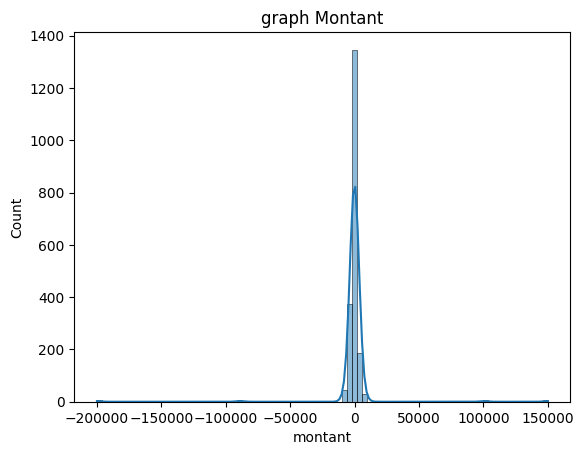

In [78]:
# Bar graph : montant
plt.title("graph Montant")
sns.histplot(df["montant"],kde=True)
plt.show()

In [79]:
df['montant'].skew()

np.float64(-3.630497025419702)

In [80]:
Q1 = df['montant'].quantile(0.25)
Q3 = df['montant'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


score_credit_client

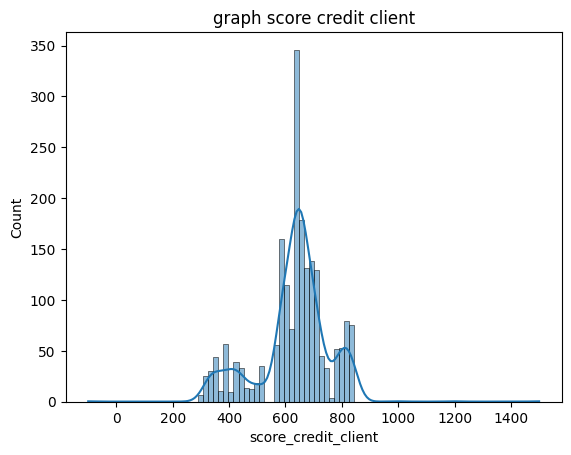

In [81]:
#Bar graph : score credit client
plt.title("graph score credit client")
sns.histplot(df["score_credit_client"],kde=True)
plt.show()

In [82]:
df['score_credit_client'].skew()

np.float64(-0.5542064802578116)

In [83]:
moyenne=df['score_credit_client'].mean()
ecart_type=df['score_credit_client'].std()
z_score=(df['score_credit_client']-moyenne)/ecart_type

calcule les anomalises


In [84]:
df['is_anomaly'] = (
    (df['montant'] < lower) |
    (df['montant'] > upper) |
    ((df['score_credit_client'] < 0) | (df['score_credit_client'] > 850)) 
)
df

,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,agence,type_operation,statut,score_credit_client,segment_client,solde_avant,taux_interet,is_anomaly
0,TXN000559,CLI0060,2022-04-19 02:31:00,2050.42,EUR,1.00,2050.42,Depot especes,Compte Epargne,Marseille-Vieux-Port,Credit,Complete,645.0,Premium,16415.10,NaN,False
1,TXN001154,CLI0057,2024-06-20 20:51:00,-123.66,GBP,0.86,-143.79,Retrait DAB,Credit Consommation,Unknown,Debit,Rejete,435.0,Risque,42890.81,NaN,False
2,TXN000764,CLI0015,2024-08-28 05:03:00,-396.17,EUR,1.00,-396.17,Prelevement,PEA,Lyon-Part-Dieu,Debit,Complete,648.0,Standard,48489.38,NaN,False
3,TXN001598,CLI0045,2024-01-07 08:16:00,225.20,EUR,1.00,225.20,Paiement CB,Credit Consommation,Bordeaux-Meriadeck,Credit,Complete,704.0,Standard,43962.51,NaN,False
4,TXN001873,CLI0034,2024-08-11 19:52:00,935.32,EUR,1.00,935.32,Interets,Credit Immobilier,Bordeaux-Meriadeck,Credit,Complete,457.0,Risque,17312.83,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2054,TXN001973,CLI0085,2022-07-12 08:13:00,-5814.40,EUR,1.00,-5814.40,Virement international,Livret A,Toulouse-Capitole,Debit,Complete,390.0,Risque,33342.90,NaN,True
2056,TXN001769,CLI0040,2024-03-28 11:34:00,296.96,EUR,1.00,296.96,Virement,Credit Immobilier,Unknown,Credit,Complete,491.0,Risque,18507.38,NaN,False
2057,TXN001738,CLI0106,NaT,-2106.58,EUR,1.00,-2106.58,Virement international,Assurance Vie,Nantes-Commerce,Debit,Complete,652.0,Standard,42428.00,NaN,False
2058,TXN001210,CLI0098,2024-02-18 12:02:00,-353.74,CHF,0.97,-364.68,Retrait DAB,Compte Epargne,Bordeaux-Meriadeck,Debit,Complete,580.0,Standard,40176.99,NaN,False


# 4️⃣ Feature Engineering

In [85]:
df["annee"]=df["date_transaction"].dt.year
df["mois"]=df["date_transaction"].dt.month
df["trimestre"]=df["date_transaction"].dt.quarter
df["jour_semaine"]=df["date_transaction"].dt.day
#Calculer montant_eur_verifie
df['montant_eur_verifie'] = df['montant'] / df['taux_change_eur']
from fonc_categorie_risque import categorie_risque
df['categorie_risque'] = df['score_credit_client'].apply(categorie_risque)
df

,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,agence,...,segment_client,solde_avant,taux_interet,is_anomaly,annee,mois,trimestre,jour_semaine,montant_eur_verifie,categorie_risque
0,TXN000559,CLI0060,2022-04-19 02:31:00,2050.42,EUR,1.00,2050.42,Depot especes,Compte Epargne,Marseille-Vieux-Port,...,Premium,16415.10,NaN,False,2022.0,4.0,2.0,19.0,2050.420000,Medium
1,TXN001154,CLI0057,2024-06-20 20:51:00,-123.66,GBP,0.86,-143.79,Retrait DAB,Credit Consommation,Unknown,...,Risque,42890.81,NaN,False,2024.0,6.0,2.0,20.0,-143.790698,High
2,TXN000764,CLI0015,2024-08-28 05:03:00,-396.17,EUR,1.00,-396.17,Prelevement,PEA,Lyon-Part-Dieu,...,Standard,48489.38,NaN,False,2024.0,8.0,3.0,28.0,-396.170000,Medium
3,TXN001598,CLI0045,2024-01-07 08:16:00,225.20,EUR,1.00,225.20,Paiement CB,Credit Consommation,Bordeaux-Meriadeck,...,Standard,43962.51,NaN,False,2024.0,1.0,1.0,7.0,225.200000,Low
4,TXN001873,CLI0034,2024-08-11 19:52:00,935.32,EUR,1.00,935.32,Interets,Credit Immobilier,Bordeaux-Meriadeck,...,Risque,17312.83,NaN,False,2024.0,8.0,3.0,11.0,935.320000,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2054,TXN001973,CLI0085,2022-07-12 08:13:00,-5814.40,EUR,1.00,-5814.40,Virement international,Livret A,Toulouse-Capitole,...,Risque,33342.90,NaN,True,2022.0,7.0,3.0,12.0,-5814.400000,High
2056,TXN001769,CLI0040,2024-03-28 11:34:00,296.96,EUR,1.00,296.96,Virement,Credit Immobilier,Unknown,...,Risque,18507.38,NaN,False,2024.0,3.0,1.0,28.0,296.960000,High
2057,TXN001738,CLI0106,NaT,-2106.58,EUR,1.00,-2106.58,Virement international,Assurance Vie,Nantes-Commerce,...,Standard,42428.00,NaN,False,NaN,NaN,NaN,NaN,-2106.580000,Medium
2058,TXN001210,CLI0098,2024-02-18 12:02:00,-353.74,CHF,0.97,-364.68,Retrait DAB,Compte Epargne,Bordeaux-Meriadeck,...,Standard,40176.99,NaN,False,2024.0,2.0,1.0,18.0,-364.680412,Medium


In [86]:
df['date_transaction'] = df['date_transaction'].fillna("Unknown")
df['annee'] = df['annee'].fillna("Unknown")
df['mois'] = df['mois'].fillna("Unknown")
df['trimestre'] = df['trimestre'].fillna("Unknown")
df['jour_semaine'] = df['jour_semaine'].fillna("Unknown")

In [99]:
# Solde net par client 
solde_net=df.groupby(['client_id','type_operation'])['montant'].sum().unstack(fill_value=0)
solde_net['solde_net']=solde_net['Credit']-solde_net['Debit']
solde_net=solde_net['solde_net']
solde_net

client_id
CLI0001    23886.54
CLI0002    13138.46
CLI0003    20457.45
CLI0004    15621.52
CLI0005    13259.31
             ...   
CLI0146    14791.59
CLI0147    19107.75
CLI0148    19508.75
CLI0149     6825.35
CLI0150     9894.40
Name: solde_net, Length: 150, dtype: float64

In [88]:
# Agréger par client
Agréger_client = df.groupby('client_id').agg({
    'transaction_id': 'count',
    'montant': 'mean',
    'produit': 'nunique'
}).reset_index()

Agréger_client.columns = ['client_id', 'nb_transactions', 'montant_moyen', 'nb_produits']

df = df.merge(Agréger_client, on='client_id', how='left')
df

,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,agence,...,is_anomaly,annee,mois,trimestre,jour_semaine,montant_eur_verifie,categorie_risque,nb_transactions,montant_moyen,nb_produits
0,TXN000559,CLI0060,2022-04-19 02:31:00,2050.42,EUR,1.00,2050.42,Depot especes,Compte Epargne,Marseille-Vieux-Port,...,False,2022.0,4.0,2.0,19.0,2050.420000,Medium,12,1200.871667,7
1,TXN001154,CLI0057,2024-06-20 20:51:00,-123.66,GBP,0.86,-143.79,Retrait DAB,Credit Consommation,Unknown,...,False,2024.0,6.0,2.0,20.0,-143.790698,High,9,-379.136667,7
2,TXN000764,CLI0015,2024-08-28 05:03:00,-396.17,EUR,1.00,-396.17,Prelevement,PEA,Lyon-Part-Dieu,...,False,2024.0,8.0,3.0,28.0,-396.170000,Medium,11,-300.231818,5
3,TXN001598,CLI0045,2024-01-07 08:16:00,225.20,EUR,1.00,225.20,Paiement CB,Credit Consommation,Bordeaux-Meriadeck,...,False,2024.0,1.0,1.0,7.0,225.200000,Low,17,-630.922353,7
4,TXN001873,CLI0034,2024-08-11 19:52:00,935.32,EUR,1.00,935.32,Interets,Credit Immobilier,Bordeaux-Meriadeck,...,False,2024.0,8.0,3.0,11.0,935.320000,High,13,26.430769,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,TXN001973,CLI0085,2022-07-12 08:13:00,-5814.40,EUR,1.00,-5814.40,Virement international,Livret A,Toulouse-Capitole,...,True,2022.0,7.0,3.0,12.0,-5814.400000,High,16,-724.453125,8
1996,TXN001769,CLI0040,2024-03-28 11:34:00,296.96,EUR,1.00,296.96,Virement,Credit Immobilier,Unknown,...,False,2024.0,3.0,1.0,28.0,296.960000,High,19,434.803684,7
1997,TXN001738,CLI0106,Unknown,-2106.58,EUR,1.00,-2106.58,Virement international,Assurance Vie,Nantes-Commerce,...,False,Unknown,Unknown,Unknown,Unknown,-2106.580000,Medium,16,-257.029375,8
1998,TXN001210,CLI0098,2024-02-18 12:02:00,-353.74,CHF,0.97,-364.68,Retrait DAB,Compte Epargne,Bordeaux-Meriadeck,...,False,2024.0,2.0,1.0,18.0,-364.680412,Medium,15,-866.908000,8


In [89]:
# taux_rejet
taux_rejet = df.groupby('agence')['statut'].apply(
    lambda x: (x == 'Rejete').mean()
).reset_index(name='taux_rejet')

df = df.merge(taux_rejet, on='agence', how='left')
taux_rejet

,agence,taux_rejet
0,Bordeaux-Meriadeck,0.045198
1,Lille-Grand-Place,0.042056
2,Lyon-Part-Dieu,0.040134
3,Marseille-Vieux-Port,0.055728
4,Nantes-Commerce,0.085000
5,Nice-Massena,0.076336
6,Paris-Centre,0.065789
7,Toulouse-Capitole,0.068063
8,Unknown,0.050000


In [91]:
df['taux_interet'] = df['taux_interet'].fillna("Unknown")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       2000 non-null   object 
 1   client_id            2000 non-null   object 
 2   date_transaction     2000 non-null   object 
 3   montant              2000 non-null   float64
 4   devise               2000 non-null   object 
 5   taux_change_eur      2000 non-null   float64
 6   montant_eur          2000 non-null   float64
 7   categorie            2000 non-null   object 
 8   produit              2000 non-null   object 
 9   agence               2000 non-null   object 
 10  type_operation       2000 non-null   object 
 11  statut               2000 non-null   object 
 12  score_credit_client  2000 non-null   float64
 13  segment_client       2000 non-null   object 
 14  solde_avant          2000 non-null   float64
 15  taux_interet         2000 non-null   o

In [92]:
df.to_csv("financecore_clean.csv", index=False)